We used the three variables SSMX3, SSMX4, SSMX5 to predict MORTSTAT.

In [8]:
#First, import relevant libraries and modules. 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

#Next, update and load cleaned dataset and keep relevant columns
merged_df = pd.read_csv("merged_demo_mortality_caffeine.csv")
cols = ["SEQN", "ELIGSTAT", "MORTSTAT", "PERMTH_INT", "RIDAGEEX", "RIAGENDR",
        "WTSSCAF2", "WTSSCAF4",
        "SSMX3", "SSMX3LC", "SSMX4", "SSMX4LC", "SSMX5", "SSMX5LC",
        "SSMX6", "SSMX6LC", "SSMX7", "SSMX7LC"]

working_df = merged_df[cols].copy()
working_df.to_csv("working_df.csv", index=False)
df_q3 = working_df[["MORTSTAT", "SSMX3", "SSMX4", "SSMX5"]].dropna()

In [ ]:
X = df_q3[["SSMX3", "SSMX4", "SSMX5"]]
y = df_q3["MORTSTAT"].astype(int)

#Split the data into training and testing (80% vs 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#standardized the variables to prevent bias in distance-based algorithms like KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
#CTesting k values between 1 and 20 and selecting the highest accuracy to determine the best k for KNN
k_values = range(1, 21)
accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
best_k = k_values[np.argmax(accuracies)]
print("Best k:", best_k)

Best k: 8


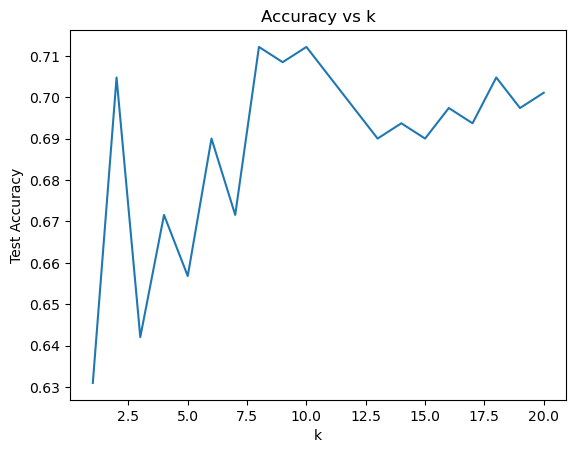

In [23]:
plt.plot(k_values, accuracies)
plt.xlabel("k")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs k")
plt.show()
#This graph shows which k value gives the highest accuracy, which is 8 in this case.

In [ ]:
#Fit the final kNN model using the selected best value of k 
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)
#Finally, generate predictions on the test set and evaluate the final model's performance
y_final_pred = final_model.predict(X_test_scaled)

print("Final Accuracy:", accuracy_score(y_test, y_final_pred))

Final Accuracy: 0.7121771217712177


To predict MORTSTAT, I used a k-Nearest classifier with the variables SSMX3, SSMX4, and SSMX5 as predictors. After cleaning and removing missing variables and keeping only relevant columns, I split the data into 80% training and 20% testing. Additionally, I standardized the predictors before fitting the model. 

Next, to select k, I tested values from 1 to 20 and calculated the testing accuracy for each value, as done on the homework. Finally, upon looking at the graph and calculations, I chose the k that produced the highest test accuracy. This is important as a small k value overfits data, while large k values tend to overfit. Selecting a k with the highest test accuracy reduces bias and variance in the data. 

Finally, using the optimal k, I created the final model with a test accuracy of 0.7121771217712177.